# PySpark Project
**Course: Large Scale Student Management**  
**Professor: Vania Marangozova**  
**Students: Daniel Beqaj, Eya**  

##### All the following analysis is conducted on our data sample (60 to 64) instead of the whole dataset.
---
## Question 1 — *What is the distribution of the machines according to their CPU capacity?*

In *machine_events* we can find information about the machines of the system. <br>
Every row of the csv file contains an event recorded in a certain timestamp for a specific machine identified by its unique id. <br>
The information about a machine's capacity can be found in the fifth field, where the values are normalized between 0 and 1 in proportion to the maximum CPU capacity. <br>
For the distribution of the machines according to CPU, we need to take one single event that represent a unique machine. Otherwise, we risk to perturbate the real distribution by the occurrencies of events of some machines that change state frequently. <br>
More explanation can be found in the code comments.



In [1]:
import sys
from pyspark import SparkContext

# Initialising Spark with 1 worker thread
sc = SparkContext("local[1]")

machine_events = sc.textFile("./data/machine_events/part-00000-of-00001.csv.gz")

# Exploring the dataset of machine_events
print("\n" + "="*80)
print(f"Number of machine_events records: {machine_events.count()}")
print(f"First line : ")
print({machine_events.first()})
print(f"Type of the elements : {type(machine_events.first())}")

machine_CPUs_values = (
    machine_events
    .map(lambda line: line.split(",")[4])   # extract CPUs column
    .distinct()
)

print("\n" + "="*80)
print(f"Number of distinct values for CPUs: {machine_CPUs_values.count()}")
print("Values of CPUs:")
print(machine_CPUs_values.take(5))

distribution_machine_CPUs = (
    machine_events
    .map(lambda line: (line.split(",")[1],line.split(",")[4]))  # each element (machine_ID,capacity_CPU)
    .reduceByKey(lambda x1, w2: x1)                             # keeps only the first distinct machine_ID
    .map(lambda x: (x[1],1))                                    # only keep the CPUs for the distribution
    .reduceByKey(lambda a, b: a + b)
)

print("\n" + "="*80)
print("Distribution of the machines according to CPUs:")
print(distribution_machine_CPUs.take(5))



Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/31 00:44:48 WARN Utils: Your hostname, im2ag-mandelbrot, resolves to a loopback address: 127.0.1.1; using 152.77.81.20 instead (on interface ens18)
25/12/31 00:44:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/31 00:44:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Number of machine_events records: 37780
First line : 
{'0,5,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493'}
Type of the elements : <class 'str'>

Number of distinct values for CPUs: 4
Values of CPUs:
['0.5', '0.25', '1', '']

Distribution of the machines according to CPUs:
[('0.5', 11632), ('0.25', 123), ('1', 796), ('', 32)]


---
## Question 2 — *What is the percentage of computational power lost due to maintenance (a machine went offline and reconnected later)?*
#### The computational power is proportional to both the CPU capacity and the unavailability period of machines.

According to the **Google Document**, there are three type of events in *machine_events*:
- *ADD* a machine to the cluster (0)
- *REMOVE* a machine from the cluster (1)
- *UPDATE* the capacity of a machine (2)

By definition, a machine goes offline when its *event_type* is 1 in *machine_events*. <br>
To answer this question, we need:
- Timestamp (field 0)
- Machine_ID (field 1)
- Event_type (field 2)
- CPU capacity (field 4)

Since computational power is proportional to CPU capacity and time, we calculate:
1. **Total alive time**: Time from first event to last event for each machine
2. **Total offline time**: Cumulative time when machines are offline (between event_type 1→0 transitions)
3. Weight both by CPU capacity (assuming it remains constant per machine)

The percentage of computational power lost is:
```
(total_offline_time × CPU_capacity) / (total_existence_time × CPU_capacity) × 100
```



In [2]:
# Calculating total time alive 
machines_events_1_024 = (
    machine_events
    .map(lambda line: line.split(","))          # converting strings into fields
    .filter(lambda x: x[4] != '')
    .map(lambda x: (x[1],(int(x[0]),int(x[2]),float(x[4]))))     # key,value : ( machine_ID, (timestamp, event_type, cpu_capacityacity) )
)

total_alive_CPUs = (
    machines_events_1_024
    .map(lambda x: (x[0], (x[1][0], x[1][0], x[1][2]))) # (machine_ID , (timestamp, timestamp, CPU_capacity) )
    .reduceByKey(lambda a, b: ( min(a[0], b[0]), max(a[1], b[1]), a[2] )) # keeping CPU
    .map(lambda x: (x[1][1] - x[1][0]) * x[1][2])                         # time_alive * CPU_capacity
    .sum()
)

# Calculating total time offline

# Fuction used to calculate total offline time
def process_machine(machine_id, events):
        sorted_events = sorted(list(events), key=lambda x: x[0])  # sorts the events (timestamp, event_type, CPU_capacity) by timestamp
        
        total_offline_time = 0
        offline_start = None
        prev_event_type = None
        
        for timestamp, event_type, cpu_capacity in sorted_events:    # looping and unpacking
            # Goes from online (1) to offline (0)
            if prev_event_type == 1 and event_type == 0:
                offline_start = timestamp
            # Goes from offline (0) to online (1)
            elif prev_event_type == 0 and event_type == 1 and offline_start is not None:
                total_offline_time = total_offline_time + (timestamp - offline_start)
                offline_start = None
            
            prev_event_type = event_type
        
        return (machine_id, total_offline_time, cpu_capacity)
    
total_offline_CPUs = (
    machines_events_1_024           # key,value : ( machine_ID, (timestamp, event_type, CPU_capacity) )
    .filter(lambda x: x[1][1]!=2)   # exclude the UPDATE events
    .groupByKey()
    .map(lambda x: (process_machine(x[0], x[1]))) # (machine_id, total_offline_time, cpu_capacity)
    .map(lambda x: (x[1]*x[2]))     # time_offline * CPU_capacity
    .sum()
)

# Printing the result
result = (total_offline_CPUs / total_alive_CPUs) * 100
print("\n" + "="*80)
print(f"Percentage of lost computational power: {result}")


Percentage of lost computational power: 18.462309039750348


---
## Question 4 — *What is the distribution of the number of jobs/tasks per scheduling class?*

This question is similar to the first one. The analysis has been done on the tast_events, where we make the distribution of the tasks according to the schedulling classes. The scheduling class is a number from 0 to 3 in ascending order of latency-sensitivity.
As the results show the majority of tasks have low latency-sensistivity, which can be scheduled for later if more important tasks come up with higher priorities.

In [3]:
# Loading the datasets into RDDs
job_events_1 = sc.textFile("./data/job_events/part-00060-of-00500.csv.gz")
job_events_2 = sc.textFile("./data/job_events/part-00061-of-00500.csv.gz")
job_events_3 = sc.textFile("./data/job_events/part-00062-of-00500.csv.gz")
job_events_4 = sc.textFile("./data/job_events/part-00063-of-00500.csv.gz")
job_events_4 = sc.textFile("./data/job_events/part-00064-of-00500.csv.gz")

job_events= job_events_1.union(job_events_2).union(job_events_3).union(job_events_4)


task_events_1 = sc.textFile("./data/task_events/part-00060-of-00500.csv.gz")
task_events_2 = sc.textFile("./data/task_events/part-00061-of-00500.csv.gz")
task_events_3 = sc.textFile("./data/task_events/part-00062-of-00500.csv.gz")
task_events_4 = sc.textFile("./data/task_events/part-00063-of-00500.csv.gz")
task_events_4 = sc.textFile("./data/task_events/part-00064-of-00500.csv.gz")

task_events= task_events_1.union(task_events_2).union(task_events_3).union(task_events_4)

# Exploring the dataset
print("\n" + "="*80)
task_events = (
    task_events
    .map(lambda line: line.split(","))
)
scheduling_classes = (
    task_events
    .map(lambda x : x[7])
    .distinct()
)
print(f"Values for scheduling_classes: {scheduling_classes.take(5)}")
total_jobs = (
    job_events
    .count()
)
print(f"Total number of jobs: {total_jobs}")
total_tasks = (
    task_events
    .count()
)
print(f"Total number of tasks: {total_tasks}")

# Computing the distribution
print("\n" + "="*80)
distribution_tasks_sclass = (
    task_events
    .map(lambda x: x[7])
    .map(lambda x: (x,1))
    .reduceByKey(lambda a, b: a + b)
)
print(f"Distribution of tasks according to the scheduling_class: {distribution_tasks_sclass.take(5)}")

Values for scheduling_classes: ['1', '2', '0', '3']
Total number of jobs: 14988


Total number of tasks: 720681



Distribution of tasks according to the scheduling_class: [('1', 120164), ('2', 100608), ('0', 485128), ('3', 14781)]


---
## Question 6 — *Do tasks with a low scheduling class have a higher probability of being evicted?*

Similar to the previous question, we need to check the distribution of *evicted_tasks* according to their *scheduling_class*. <br>
In the *task_events* dataset, the identifier of a taks is the couple (job_id, task_idx). By filtering the dataset to only keep the evicted_tasks and then only keeping the scheduling_class, we can make the distribution of the evictions according to the scheduling_class. <br>
As it appears, low scheduling classes tend to have more evictions than tasks with higher scheduling classes.

In [4]:
evicted_tasks = (
    task_events
    .filter(lambda x: x[5] == '2')
    .map(lambda x: ((x[2],x[3]),(x[5],x[7])))  # (job_id, task_idx) (event_type,scheduling_class)
)
print(f"Number of evictions: {evicted_tasks.count()}")
distinct_evicted_tasks = evicted_tasks.distinct()
print(f"Number of distinct tasks evicted at least once: {distinct_evicted_tasks.count()}")

distribution_sclass_eviction = (
    distinct_evicted_tasks
    .map(lambda x: x[1][1])
    .map(lambda x: (x,1))
    .reduceByKey(lambda a, b: a + b)
)
print("\n" + "="*80)
print(f"Distribution of evited_tasks according to the scheduling_class: {distribution_sclass_eviction.take(10)}")

Number of evictions: 30341


Number of distinct tasks evicted at least once: 19704

Distribution of evited_tasks according to the scheduling_class: [('2', 3714), ('1', 3566), ('0', 12230), ('3', 194)]


---
## Question 8 — *Are the tasks that request the more resources the one that consume the more resources?*

Information about the request of the resources can be found in *task_events*, while the real consumption of the resources is recorded in *task_usage*. <br>
The first analysis is based on the comparison of requested and used **RAM**: <br>
- From *task_events* are extracted the task IDs (job_id, task_idx) and the corresponding requested RAM, but removing duplicates (in case multiple events are recorded per task).
- From *task_usage* are extracted the task IDs and, to simplify, the mean of the recorded usages of RAM.

To answer this question, there are two indicators:
- a visualisation using a **heatmap**, by categorising the values into 5 bins based on the quantiles (in order to have useful quantities for each bin)
- a **correlation** indicator that is more exact based on the raw values (real values before binning)

As it is shown by both approaches, the tasks requiring the most resources aquire the most resourses. That is explained by the heatmap colors concentrated in the diagonal and the correlation value being strong.<br>

The same analysis can be done for the other resources such as CPU and disk usage.





In [5]:
# Loading the dataset
task_usage_1 = sc.textFile("./data/task_usage/part-00060-of-00500.csv.gz")
task_usage_2 = sc.textFile("./data/task_usage/part-00061-of-00500.csv.gz")
task_usage_3 = sc.textFile("./data/task_usage/part-00062-of-00500.csv.gz")
task_usage_4 = sc.textFile("./data/task_usage/part-00063-of-00500.csv.gz")
task_usage_4 = sc.textFile("./data/task_usage/part-00064-of-00500.csv.gz")

task_usage= task_usage_1.union(task_usage_2).union(task_usage_3).union(task_usage_4)
task_usage = (
    task_usage
    .map(lambda line: line.split(","))      # transforming strings into fields
)

# Exploring the dataset
CPU_values_events_table = (
    task_events
    .map(lambda x : float(x[9]))
    .distinct()
)
print("\n" + "="*80)
print(f"Number of records in task_usage: {task_usage.count()}")
print(f"Total of CPU_values_events_table : {CPU_values_events_table.count()}")
print(f"Min of CPU_values_events_table : {CPU_values_events_table.min()}")
print(f"Max of CPU_values_events_table : {CPU_values_events_table.max()}")


Number of records in task_usage: 9098029


Total of CPU_values_events_table : 218
Min of CPU_values_events_table : 0.0
Max of CPU_values_events_table : 0.4375


Quantiles for req RAM: [0.007767 0.0159   0.0318   0.04773  0.5088  ]


Quantiles for used RAM: [4.43539030e-04 1.45400000e-03 5.61707242e-03 1.61906667e-02
 7.68600000e-01]


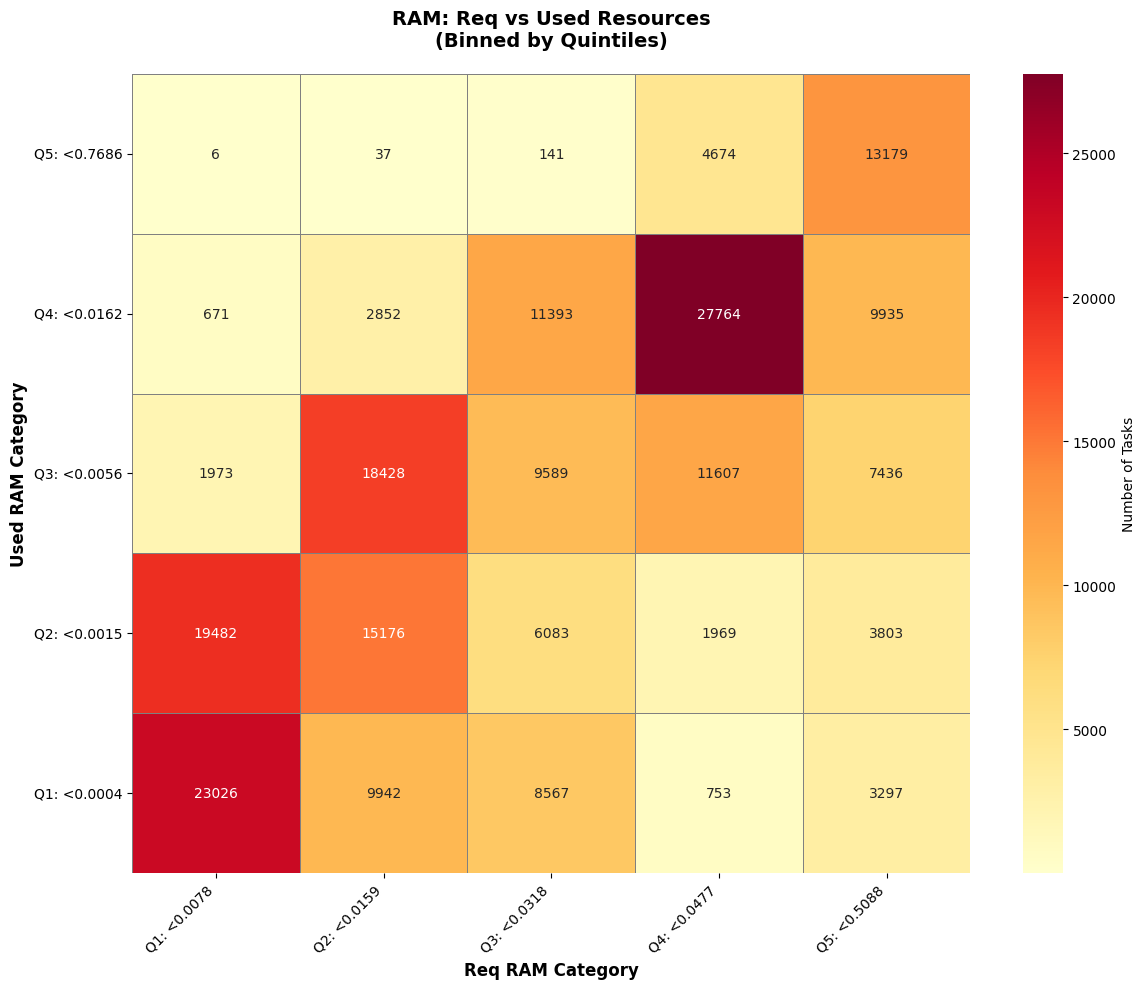


STATISTICS
Total tasks: 211783


Pearson Correlation: 0.7071
Interpretation: STRONG positive correlation


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

task_events_reqRAM = (          # comes from task_events and concentrates on reqRAM
    task_events
    .map(lambda x: ((x[2], x[3]), float(x[10])))  # ( (job_id, task_idx), reqRAM )
    .distinct()                 # removing duplicates     
)

task_usage_usedRAM = (      # comes from task_usage and concentrates on usedRAM
    task_usage
    .map(lambda x: ((x[2], x[3]), float(x[6])))  # ( (job_id, task_idx), used RAM )
    .groupByKey()
    .mapValues(lambda x: np.mean(list(x)))  # average across all measurements
)

# Quantiles for req RAM
req_distribution = task_events_reqRAM.map(lambda x: x[1]).collect()
req_quantiles = np.quantile(req_distribution, [0.2, 0.4, 0.6, 0.8, 1.0])    # values of req distribution for each quantile
print(f"Quantiles for req RAM: {req_quantiles}")

# Quantiles for used RAM
used_distribution = task_usage_usedRAM.map(lambda x: x[1]).collect()
used_quantiles = np.quantile(used_distribution, [0.2, 0.4, 0.6, 0.8, 1.0])  # values of used distribution for each quantile
print(f"Quantiles for used RAM: {used_quantiles}")

# Binning functions to categorise values into 5 bins 
# each bin corresponds to the quantile
def reqRAM_value_to_range(x):
    if float(x) < req_quantiles[0]:   return 0
    elif float(x) < req_quantiles[1]: return 1
    elif float(x) < req_quantiles[2]: return 2
    elif float(x) < req_quantiles[3]: return 3
    else: return 4
def usedRAM_value_to_range(x):
    if float(x) < used_quantiles[0]:   return 0
    elif float(x) < used_quantiles[1]: return 1
    elif float(x) < used_quantiles[2]: return 2
    elif float(x) < used_quantiles[3]: return 3
    else: return 4

# Apply binning
task_events_reqRAM_binned = (
    task_events_reqRAM
    .map(lambda x: (x[0], reqRAM_value_to_range(x[1])))  # ((job_id, task_idx), req_bin)
)
task_usage_usedRAM_binned = (
    task_usage_usedRAM
    .map(lambda x: (x[0], usedRAM_value_to_range(x[1])))  # ((job_id, task_idx), used_bin)
)

# Joining req and used 
joined_req_used_RAM = task_events_reqRAM_binned.join(task_usage_usedRAM_binned)     # ((job_id, task_idx), (req_bin, used_bin))

# Counting for every combination between req and used bins
req_used_RAM_counts = (
    joined_req_used_RAM
    .map(lambda x: ((x[1][0], x[1][1]), 1))
    .reduceByKey(lambda a, b: a + b) 
)
data = req_used_RAM_counts.collect()


######################################################
#################### VISUALISATION ###################
######################################################

df = pd.DataFrame(
    [(x1, x2, count) for ((x1, x2), count) in data],
    columns=["req_bin", "used_bin", "count"]
)

heatmap_matrix = df.pivot(index="used_bin", columns="req_bin", values="count").fillna(0)

# Bin labels
req_labels = [
    f"Q1: <{req_quantiles[0]:.4f}",
    f"Q2: <{req_quantiles[1]:.4f}",
    f"Q3: <{req_quantiles[2]:.4f}",
    f"Q4: <{req_quantiles[3]:.4f}",
    f"Q5: <{req_quantiles[4]:.4f}"
]
used_labels = [
    f"Q1: <{used_quantiles[0]:.4f}",
    f"Q2: <{used_quantiles[1]:.4f}",
    f"Q3: <{used_quantiles[2]:.4f}",
    f"Q4: <{used_quantiles[3]:.4f}",
    f"Q5: <{used_quantiles[4]:.4f}"
]

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    heatmap_matrix, 
    annot=True,
    fmt='g',
    cmap='YlOrRd',
    cbar_kws={'label': 'Number of Tasks'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

ax.invert_yaxis()

ax.set_xlabel('Req RAM Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Used RAM Category', fontsize=12, fontweight='bold')
ax.set_title(
    'RAM: Req vs Used Resources\n(Binned by Quintiles)',
    fontsize=14,
    fontweight='bold',
    pad=20
)

ax.set_xticklabels(req_labels, rotation=45, ha='right')
ax.set_yticklabels(used_labels, rotation=0)

plt.tight_layout()
plt.show()


######################################################
#################### STATISTICS ######################
######################################################

print("\n" + "="*80)
print("STATISTICS")

total_tasks = heatmap_matrix.sum().sum()
print(f"Total tasks: {total_tasks:.0f}")

# Calculate correlation on raw values (not binned)
req_used_values = (
    task_events_reqRAM
    .join(task_usage_usedRAM)
    .map(lambda x: (x[1][0], x[1][1]))  # (req, used)
    .filter(lambda x: x[0] > 0 and x[1] > 0)  # filter zeros
    .collect()
)
req_vals = [x[0] for x in req_used_values]
used_vals = [x[1] for x in req_used_values]
correlation, p_value = pearsonr(req_vals, used_vals)
print(f"Pearson Correlation: {correlation:.4f}")
print(f"Interpretation: ", end="")
if correlation > 0.7:
    print("STRONG positive correlation")
elif correlation > 0.3:
    print("MODERATE positive correlation")
else:
    print("WEAK correlation")

---
## Question 10 — *How often does it happen that the resources of a machine are over-committed?*

In [7]:
# Get machine capacities with proper error handling
machine_capacities = (
    machine_events
    .map(lambda line: line.split(","))     # converting strings into fields
    .filter(lambda x: x[2] in ['0', '2'])  # keep only ADD or UPDATE
    .filter(lambda x: x[4] != '' and x[5] != '')  # keep only events that have values for CPU and memory
    .map(lambda x: ( x[1], (int(x[0]), float(x[4]), float(x[5]) ))) # ( machine_id, (timestamp, cpu_capacity, memory_capacity) )
    .reduceByKey(lambda a, b: a if a[0] > b[0] else b)  # removing the duplicates by only keeping the most recent value
    .mapValues(lambda x: (x[1], x[2]))  # keep only (cpu_capacity, mem_capacity)
)

print("\n" + "="*80)
machine_count = machine_capacities.count()
print(f"Total machines with capacity info: {machine_count}")
capacities_dict = dict(machine_capacities.collect()) # dictionary for faster lookup

scheduled_by_machine = (
    task_events  # already converted to strings into fields
    .filter(lambda x: x[5] == '1')      # keep only SCHEDULE events
    .filter(lambda x: x[9] != '' and x[10] != '')   # removing rows with missing values
    .map(lambda x: (x[4], (float(x[9]), float(x[10])))) # ( machine_id, (cpu_request, mem_request) )
    .groupByKey()
)

scheduled_machine_count = scheduled_by_machine.count()
print(f"Machines with scheduled tasks: {scheduled_machine_count}")

# to check overcommitment for a given machine
def check_overcommitment(machine_id, requests, capacities_dict):
    if machine_id not in capacities_dict:
        return None
    
    cpu_capacity, mem_capacity = capacities_dict[machine_id]
    requests_list = list(requests)
    
    # Sum all requests
    total_cpu = sum([r[0] for r in requests_list])
    total_mem = sum([r[1] for r in requests_list])
    
    # Check over-commitment
    cpu_overcommit = total_cpu > cpu_capacity
    mem_overcommit = total_mem > mem_capacity
    
    return {
        'machine_id': machine_id,
        'cpu_capacity': cpu_capacity,
        'cpu_overcommit': cpu_overcommit,
        'mem_capacity': mem_capacity,
        'mem_overcommit': mem_overcommit,
        'overcommitted': cpu_overcommit or mem_overcommit
    }

# applying overcommitment check
overcommit_results = []
for machine_id, requests in scheduled_by_machine.collect():     # where request = (cpu_request, mem_request)
    result = check_overcommitment(machine_id, requests, capacities_dict)
    if result:
        overcommit_results.append(result)

# converting to DataFrame
df = pd.DataFrame(overcommit_results)

print("\n" + "="*80)
print("OVERCOMMITMENT RESULTS")

total_machines = len(df)
cpu_overcommit_count = df['cpu_overcommit'].sum()
mem_overcommit_count = df['mem_overcommit'].sum()

print(f"\nTotal machines analyzed: {total_machines}")

print(f"CPU Over-commitment -> Machines: {cpu_overcommit_count} ({cpu_overcommit_count/total_machines*100:.2f}%)")

print(f"Memory Over-commitment -> Machines: {mem_overcommit_count} ({mem_overcommit_count/total_machines*100:.2f}%)")


Total machines with capacity info: 12583


Machines with scheduled tasks: 12157

OVERCOMMITMENT RESULTS

Total machines analyzed: 12157
CPU Over-commitment -> Machines: 5510 (45.32%)
Memory Over-commitment -> Machines: 5420 (44.58%)


---
## Question 12 — *What is the final state of tasks once they have been scheduled and executed on machines?*

Once the tasks have been scheduled and running, most of the tasks finish, while some of them are killed. Very few tasks fail or are evicted.


Final distribution of task states (EVICT, FAIL, FINISH, KILL, LOST):


[(4, 127208), (5, 44796), (2, 6), (3, 815)]


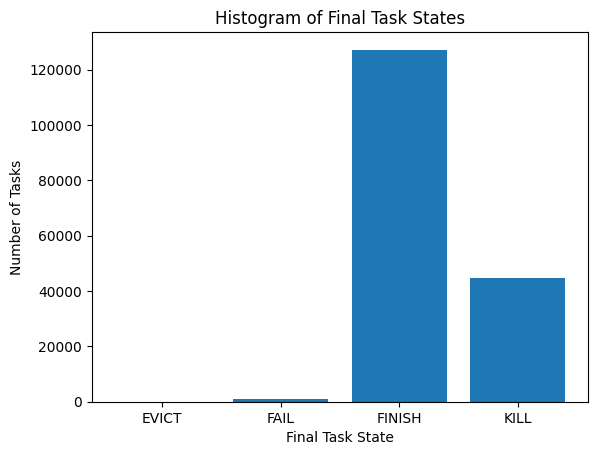

In [8]:
task_events_23_05 = (
    task_events
    .map(lambda x: ( (x[2], x[3]), (int(x[0]), x[5]) )) # ( (job_id, task_idx), (timestamp, event_type) )
)

final_state_distribution = (
    task_events_23_05
    .reduceByKey(lambda a, b: a if a[0] > b[0] else b)   # keep last event
    .map(lambda x: int(x[1][1]))                         # event_type
    .filter(lambda e: e in [2, 3, 4, 5, 6])              # EVICT, FAIL, FINISH, KILL, LOST
    .map(lambda e: (e, 1))
    .reduceByKey(lambda a, b: a + b)
)

print("\n" + "="*80)
print("Final distribution of task states (EVICT, FAIL, FINISH, KILL, LOST):")
results = final_state_distribution.collect()
print(results)

# Plotting a histogram
results = sorted(results, key=lambda x: x[0])
labels = {
    2: "EVICT",
    3: "FAIL",
    4: "FINISH",
    5: "KILL",
    6: "LOST"
}

labels = [labels[e] for e, _ in results]
counts = [c for _, c in results]

plt.figure()
plt.bar(labels, counts)
plt.xlabel("Final Task State")
plt.ylabel("Number of Tasks")
plt.title("Histogram of Final Task States")
plt.show()

